In [25]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
from tabulate import tabulate
import seaborn as sns
import copy
from matplotlib.patches import FancyArrowPatch, Circle




# TEST: Architecture Sampling


In [5]:

def sample_architecture(alpha, k=2):
    num_nodes = 7
    device = alpha.device
    
    op_names = ['sep_conv_3x3', 'sep_conv_5x5', 'dil_conv_3x3', 'dil_conv_5x5',
               'max_pool_3x3', 'avg_pool_3x3', 'identity', 'zero']
    
    sampled_arch = {}
    offset = 0
    
    for node_idx in range(num_nodes - 2):  # 5 intermediate nodes (0-4)
        num_predecessors = 2 + node_idx
        edges_for_node = []
        
        # Collect all edges for this node with their best operations
        for pred_idx in range(num_predecessors):
            if offset >= alpha.shape[0]:
                print(f"Warning: offset {offset} >= alpha.shape[0] {alpha.shape[0]}")
                break
            
            edge_alpha = alpha[offset]
            
            # Exclude zero operation (index 7) from selection
            edge_alpha_no_zero = edge_alpha.clone()
            edge_alpha_no_zero[7] = -float('inf')
            
            # Get best operation for this edge
            best_op_idx = edge_alpha_no_zero.argmax().item()
            best_val = edge_alpha[best_op_idx].item()  # Use original value for sorting
            
            edges_for_node.append((pred_idx, best_op_idx, best_val))
            offset += 1
        
        # Keep only top-k edges by strength for this node
        edges_for_node.sort(key=lambda x: x[2], reverse=True)
        edges_for_node = edges_for_node[:k]
        
        # Store in architecture dict
        for pred_idx, op_idx, strength in edges_for_node:
            edge_key = f'{pred_idx}_{node_idx}'
            sampled_arch[edge_key] = op_names[op_idx]
    
    return sampled_arch


def print_architecture(arch, title="Architecture"):
    
    print(f"\n{title}")
    print("=" * 60)
    
    for node_idx in range(5):
        node_edges = [(int(k.split('_')[0]), v) for k, v in arch.items() 
                     if int(k.split('_')[1]) == node_idx]
        if node_edges:
            print(f"Node {node_idx + 2}:")
            for pred_idx, op_name in sorted(node_edges):
                print(f"  from Node {pred_idx}: {op_name}")


# ============================================================================
# TEST EXECUTION
# ============================================================================

print("="*70)
print("DARTS Architecture Sampling Test")
print("="*70)

# Test 1: Check alpha tensor shape
print("\n[Test 1: Alpha tensor shape]")
alpha = torch.randn(14, 8)
print(f"Alpha shape: {alpha.shape}")
print(f"Expected: (14, 8) for 14 edges and 8 operations")

# Test 2: Sample first architecture
print("\n[Test 2: Sample Architecture 1]")
arch1 = sample_architecture(alpha.clone(), k=2)
print(f"Number of edges in architecture: {len(arch1)}")
print(f"Expected: up to 10 edges (2 edges per node × 5 nodes)")
print_architecture(arch1, "Architecture 1")

# Test 3: Different alpha produces different architecture
print("\n[Test 3: Different Alpha → Different Architecture]")
alpha2 = torch.randn(14, 8)
arch2 = sample_architecture(alpha2.clone(), k=2)
print(f"Architecture 1 == Architecture 2: {arch1 == arch2}")
print("Expected: False (different alpha values should produce different archs)")
print_architecture(arch2, "Architecture 2")

# Test 4: Same alpha produces same architecture
print("\n[Test 4: Same Alpha → Same Architecture]")
alpha_copy = alpha.clone()
arch1_repeat = sample_architecture(alpha_copy, k=2)
print(f"Architecture 1 == Architecture 1 (repeated): {arch1 == arch1_repeat}")
print("Expected: True (same alpha should produce same architecture)")

# Test 5: Verify no zero operations in sampled arch
print("\n[Test 5: Zero Operations Exclusion]")
zero_ops = sum(1 for op in arch1.values() if op == 'zero')
print(f"Zero operations in sampled architecture: {zero_ops}")
print("Expected: 0 (zero operations should be excluded)")

# Test 6: Verify k=2 constraint
print("\n[Test 6: Top-k Selection (k=2)]")
for node_idx in range(5):
    edges_in_node = sum(1 for k in arch1.keys() 
                       if int(k.split('_')[1]) == node_idx)
    print(f"Node {node_idx}: {edges_in_node} edges (max {min(2, 2+node_idx)})")
print("Expected: At most 2 edges per node")

print("\n" + "="*70)
print("All tests completed!")
print("="*70)

# Test 7: Show weights normalization
print("\n[Test 7: Softmax Normalization]")
alpha_sample = torch.randn(1, 8)
weights = F.softmax(alpha_sample, dim=-1)
print(f"Original alpha: {alpha_sample[0]}")
print(f"After softmax: {weights[0]}")
print(f"Sum of weights: {weights.sum().item():.6f} (should be 1.0)")

print("\n✓ Architecture sampling test passed!")

DARTS Architecture Sampling Test

[Test 1: Alpha tensor shape]
Alpha shape: torch.Size([14, 8])
Expected: (14, 8) for 14 edges and 8 operations

[Test 2: Sample Architecture 1]
Number of edges in architecture: 8
Expected: up to 10 edges (2 edges per node × 5 nodes)

Architecture 1
Node 2:
  from Node 0: avg_pool_3x3
  from Node 1: dil_conv_3x3
Node 3:
  from Node 1: dil_conv_3x3
  from Node 2: sep_conv_3x3
Node 4:
  from Node 0: identity
  from Node 3: dil_conv_3x3
Node 5:
  from Node 1: sep_conv_3x3
  from Node 3: avg_pool_3x3

[Test 3: Different Alpha → Different Architecture]
Architecture 1 == Architecture 2: False
Expected: False (different alpha values should produce different archs)

Architecture 2
Node 2:
  from Node 0: dil_conv_5x5
  from Node 1: dil_conv_5x5
Node 3:
  from Node 0: sep_conv_5x5
  from Node 2: sep_conv_5x5
Node 4:
  from Node 0: sep_conv_3x3
  from Node 2: identity
Node 5:
  from Node 2: max_pool_3x3
  from Node 3: avg_pool_3x3

[Test 4: Same Alpha → Same Archit

In [6]:

# ============================================================================
# PART 1: OPERATION SET
# ============================================================================

class ReLUConvBN(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation=1):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_out, kernel_size, stride=stride, padding=padding, 
                     dilation=dilation, bias=False),
            nn.BatchNorm2d(C_out)
        )
    
    def forward(self, x):
        return self.op(x)

class SepConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation=1):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride=stride, padding=padding,
                     dilation=dilation, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out)
        )
    
    def forward(self, x):
        return self.op(x)

class FactorizedReduce(nn.Module):
    def __init__(self, C_in, C_out, stride=2):
        super().__init__()
        assert stride == 2
        self.relu = nn.ReLU(inplace=False)
        self.conv1 = nn.Conv2d(C_in, C_out // 2, 1, stride=2, padding=0, bias=False)
        self.conv2 = nn.Conv2d(C_in, C_out // 2, 1, stride=2, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(C_out)
    
    def forward(self, x):
        x = self.relu(x)
        out = torch.cat([self.conv1(x), self.conv2(x[:, :, 1:, 1:])], dim=1)
        out = self.bn(out)
        return out

class PoolBN(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, pool_type):
        super().__init__()
        self.relu = nn.ReLU(inplace=False)
        if pool_type == 'max':
            self.pool = nn.MaxPool2d(kernel_size, stride=stride, padding=padding)
        else:
            self.pool = nn.AvgPool2d(kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(C_out) if C_in == C_out else nn.Identity()
    
    def forward(self, x):
        x = self.relu(x)
        x = self.pool(x)
        x = self.bn(x)
        return x

class Identity(nn.Module):
    def forward(self, x):
        return x

class Zero(nn.Module):
    def __init__(self, stride):
        super().__init__()
        self.stride = stride
    
    def forward(self, x):
        if self.stride == 1:
            return x.mul(0.)
        else:
            return x[:, :, ::self.stride, ::self.stride].mul(0.)


In [ ]:

# ============================================================================
# PART 2: MIXED OPERATION
# ============================================================================

class MixedOp(nn.Module):
    def __init__(self, C_in, C_out, stride, dilation=1):
        super().__init__()
        self.stride = stride
        self.ops = nn.ModuleDict()
        
        self.ops['sep_conv_3x3'] = SepConv(C_in, C_out, 3, stride, 1, dilation=dilation)
        self.ops['sep_conv_5x5'] = SepConv(C_in, C_out, 5, stride, 2, dilation=dilation)
        self.ops['dil_conv_3x3'] = SepConv(C_in, C_out, 3, stride, dilation, dilation=dilation)
        self.ops['dil_conv_5x5'] = SepConv(C_in, C_out, 5, stride, 2*dilation, dilation=dilation)
        self.ops['max_pool_3x3'] = PoolBN(C_in, C_out, 3, stride, 1, 'max')
        self.ops['avg_pool_3x3'] = PoolBN(C_in, C_out, 3, stride, 1, 'avg')
        self.ops['identity'] = Identity() if stride == 1 and C_in == C_out else Zero(stride)
        self.ops['zero'] = Zero(stride)
    
    def forward(self, x, weights):

        return sum(w * op(x) for w, op in zip(weights, self.ops.values()))

# ============================================================================
# PART 3: CELL DEFINITION
# ============================================================================

class Cell(nn.Module):
    def __init__(self, num_nodes, multiplier, C_prev_prev, C_prev, C, reduction, reduction_prev):
        super().__init__()
        self.num_nodes = num_nodes
        self.multiplier = multiplier
        
        if reduction_prev:
            self.preprocess0 = FactorizedReduce(C_prev_prev, C)
        else:
            self.preprocess0 = ReLUConvBN(C_prev_prev, C, 1, 1, 0)
        
        self.preprocess1 = ReLUConvBN(C_prev, C, 1, 1, 0)
        
        self._steps = num_nodes - 2
        self._multiplier = multiplier
        
        self.edges = nn.ModuleDict()
        for i in range(self._steps):
            for j in range(2 + i):
                stride = 2 if reduction and j < 2 else 1
                edge_name = f'{j}_{i}'
                self.edges[edge_name] = MixedOp(C, C, stride)
    
    def forward(self, s0, s1, weights):
        s0 = self.preprocess0(s0)
        s1 = self.preprocess1(s1)
        
        states = [s0, s1]
        offset = 0
        
        for i in range(self._steps):
            s_list = []
            for j in range(2 + i):
                if offset >= len(weights):
                    break
                edge_weights = weights[offset]
                s_curr = self.edges[f'{j}_{i}'](states[j], edge_weights)
                s_list.append(s_curr)
                offset += 1
            
            if s_list:
                s = sum(s_list)
                states.append(s)
        
        return torch.cat(states[-self._multiplier:], dim=1)


In [ ]:

# ============================================================================
# PART 4: DARTS NETWORK WITH SEARCH SPACE
# ============================================================================

class DARTSNetwork(nn.Module):
    def __init__(self, C=16, num_classes=10, num_nodes=7, multiplier=4, stem_multiplier=3):
        super().__init__()
        self.C = C
        self.num_nodes = num_nodes
        self.multiplier = multiplier
        
        C_curr = stem_multiplier * C
        self.stem = nn.Sequential(
            nn.Conv2d(3, C_curr, 3, padding=1, bias=False),
            nn.BatchNorm2d(C_curr)
        )
        
        C_prev_prev, C_prev, C_curr = C_curr, C_curr, C
        
        self.cells = nn.ModuleList()
        reduction_prev = False
        
        self.cell_config = []
        for i in range(8):
            if i in [2, 5]:  # Reduction at positions 2 and 5 (0-indexed)
                C_curr *= 2
                reduction = True
            else:
                reduction = False
            
            cell = Cell(num_nodes, multiplier, C_prev_prev, C_prev, C_curr, reduction, reduction_prev)
            self.cells.append(cell)
            self.cell_config.append(('reduce' if reduction else 'normal', C_curr))
            
            reduction_prev = reduction
            C_prev_prev, C_prev = C_prev, multiplier * C_curr
        
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(multiplier * C_curr, num_classes)
    
    def forward(self, x, weights_normal, weights_reduce):
        s0 = s1 = self.stem(x)
        
        for i, cell in enumerate(self.cells):
            if i % 3 == 2:  # Reduction cells at i=2, 5
                weights = weights_reduce
            else:
                weights = weights_normal
            
            s0, s1 = s1, cell(s0, s1, weights)
        
        out = self.global_pooling(s1)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out
    
    def get_architecture_params(self):

        device = next(self.parameters()).device
        
        # Total edges: 2 + 3 + 4 + 5 = 14 for 5 intermediate nodes
        num_edges = 2 + 3 + 4 + 5  # Sum for nodes 0,1,2,3,4
        num_ops = 8
        
        alpha_normal = nn.Parameter(
            1e-3 * torch.randn(num_edges, num_ops, device=device)
        )
        alpha_reduce = nn.Parameter(
            1e-3 * torch.randn(num_edges, num_ops, device=device)
        )
        
        return alpha_normal, alpha_reduce
    
    def get_cell_weights(self, alpha):

        return F.softmax(alpha, dim=-1)

# ============================================================================
# PART 5: ARCHITECTURE SAMPLING
# ============================================================================

def sample_architecture(alpha, k=2):

    num_nodes = 7
    device = alpha.device
    
    sampled_arch = {}
    offset = 0
    op_names = ['sep_conv_3x3', 'sep_conv_5x5', 'dil_conv_3x3', 'dil_conv_5x5',
               'max_pool_3x3', 'avg_pool_3x3', 'identity', 'zero']
    
    for node_idx in range(num_nodes - 2):  # 5 intermediate nodes
        num_predecessors = 2 + node_idx
        edges_for_node = []
        
        # Collect all edges for this node
        for pred_idx in range(num_predecessors):
            if offset >= alpha.shape[0]:
                break
            edge_alpha = alpha[offset]
            
            # Exclude zero operation (index 7)
            edge_alpha_no_zero = edge_alpha.clone()
            edge_alpha_no_zero[7] = -float('inf')
            
            # Get best operation for this edge
            best_op_idx = edge_alpha_no_zero.argmax().item()
            best_val = edge_alpha_no_zero[best_op_idx].item()
            
            edges_for_node.append((pred_idx, best_op_idx, best_val))
            offset += 1
        
        # Keep only top-k edges by strength for this node
        edges_for_node.sort(key=lambda x: x[2], reverse=True)
        edges_for_node = edges_for_node[:k]
        
        # Store in dict format for compatibility
        sampled_arch[node_idx] = {
            f'{pred}_{node_idx}': op_names[op_idx] 
            for pred, op_idx, _ in edges_for_node
        }
    
    return sampled_arch

# ============================================================================
# PART 6: TRAINING UTILITIES
# ============================================================================

def create_data_loaders(batch_size=128, num_workers=2):

    normalize = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                    std=[0.2023, 0.1994, 0.2010])
    
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        normalize
    ])
    
    transform_val = transforms.Compose([
        transforms.ToTensor(),
        normalize
    ])
    
    train_data = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    val_data = CIFAR10(root='./data', train=False, download=True, transform=transform_val)
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, 
                             num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False,
                           num_workers=num_workers, pin_memory=True)
    
    return train_loader, val_loader

# ============================================================================
# PART 7: FIRST-ORDER AND SECOND-ORDER DARTS
# ============================================================================

class DARTSTrainer:
    
    def __init__(self, model, device, order='first'):
        self.model = model
        self.device = device
        self.order = order  # 'first' or 'second'
        
        # Get architecture parameters from model
        self.alpha_normal, self.alpha_reduce = model.get_architecture_params()
        self.alpha_normal = self.alpha_normal.to(device)
        self.alpha_reduce = self.alpha_reduce.to(device)
        
        # Architecture optimizer (Adam for alpha)
        self.arch_optimizer = optim.Adam([self.alpha_normal, self.alpha_reduce],
                                        lr=3e-4, betas=(0.9, 0.999), weight_decay=1e-3)
        # Weight optimizer (SGD for model weights)
        self.weight_optimizer = optim.SGD(model.parameters(), lr=0.025,
                                         momentum=0.9, weight_decay=3e-4)
    
    def get_weights(self):
        weights_normal = self.model.get_cell_weights(self.alpha_normal)
        weights_reduce = self.model.get_cell_weights(self.alpha_reduce)
        return weights_normal, weights_reduce
    
    def train_epoch(self, train_loader, val_loader):

        train_loss, train_acc = 0., 0.
        val_loss, val_acc = 0., 0.
        num_batches = 0
        
        # Convert iterators to lists to ensure same length
        train_list = list(train_loader)
        val_list = list(val_loader)
        min_batches = min(len(train_list), len(val_list))
        
        for idx in range(min_batches):
            x_train, y_train = train_list[idx]
            x_val, y_val = val_list[idx]
            
            x_train, y_train = x_train.to(self.device), y_train.to(self.device)
            x_val, y_val = x_val.to(self.device), y_val.to(self.device)
            
            # Update weights
            self.weight_optimizer.zero_grad()
            self.model.zero_grad()
            
            weights_normal, weights_reduce = self.get_weights()
            logits = self.model(x_train, weights_normal, weights_reduce)
            loss = F.cross_entropy(logits, y_train)
            loss.backward()
            self.weight_optimizer.step()
            
            train_loss += loss.item()
            train_acc += (logits.argmax(1) == y_train).float().mean().item()
            
            # Update architecture
            self.model.zero_grad()
            if self.order == 'first':
                self._update_arch_first_order(x_val, y_val)
            else:
                self._update_arch_second_order(x_train, y_train, x_val, y_val)
            
            # Validation accuracy
            with torch.no_grad():
                self.model.zero_grad()
                logits_val = self.model(x_val, weights_normal, weights_reduce)
                loss_val = F.cross_entropy(logits_val, y_val)
                val_loss += loss_val.item()
                val_acc += (logits_val.argmax(1) == y_val).float().mean().item()
            
            num_batches += 1
        
        # Average over batches
        if num_batches > 0:
            train_loss /= num_batches
            train_acc /= num_batches
            val_loss /= num_batches
            val_acc /= num_batches
        
        return train_loss, train_acc, val_loss, val_acc
    
    def _update_arch_first_order(self, x_val, y_val):

        self.arch_optimizer.zero_grad()
        weights_normal, weights_reduce = self.get_weights()
        
        logits = self.model(x_val, weights_normal, weights_reduce)
        loss = F.cross_entropy(logits, y_val)
        loss.backward()
        
        self.arch_optimizer.step()

    def _update_arch_second_order(self, x_train, y_train, x_val, y_val):
        
        self.arch_optimizer.zero_grad()
        
        # Get current architecture weights
        weights_normal, weights_reduce = self.get_weights()
        
        # Step 1: Compute training loss and backward
        logits_train = self.model(x_train, weights_normal, weights_reduce)
        loss_train = F.cross_entropy(logits_train, y_train)
        
        # Compute gradients w.r.t. model weights
        self.model.zero_grad()
        loss_train.backward(retain_graph=True)
        
        # Get current gradients
        grads = [p.grad.clone() if p.grad is not None else None 
                for p in self.model.parameters()]
        
        # Step 2: One-step lookahead - simulate weight update
        xi = 0.01
        self.model.zero_grad()
        
        for p, g in zip(self.model.parameters(), grads):
            if g is not None:
                p.data = p.data - xi * g.data
        
        # Step 3: Compute validation loss with lookahead weights
        logits_val = self.model(x_val, weights_normal, weights_reduce)
        loss_val = F.cross_entropy(logits_val, y_val)
        
        # Step 4: Backward through validation loss to update architecture
        loss_val.backward()
        
        # Step 5: Restore original weights
        for p, g in zip(self.model.parameters(), grads):
            if g is not None:
                p.data = p.data + xi * g.data
        
        # Step 6: Update architecture parameters
        self.arch_optimizer.step()
        
        # Clear gradients
        self.model.zero_grad()


In [9]:
        
# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Create model and data
    model = DARTSNetwork().to(device)
    train_loader, val_loader = create_data_loaders(batch_size=64)
    
    print("\n" + "="*60)
    print("DARTS Architecture Search")
    print("="*60)
    
    # Test with random alpha
    print("\n[Testing Architecture Sampling]")
    model.eval()
    alpha_test = torch.randn(14, 8)
    arch1 = sample_architecture(alpha_test)
    
    alpha_test2 = torch.randn(14, 8)
    arch2 = sample_architecture(alpha_test2)
    
    print(f"Architecture 1 differs from Architecture 2: {arch1 != arch2}")
    
    print("\nSample architecture:", arch1)
    
    print("\n[Starting First-Order DARTS Search (2 epochs)]")
    trainer_fo = DARTSTrainer(model, device, order='first')
    
    fo_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(2):
        t_loss, t_acc, v_loss, v_acc = trainer_fo.train_epoch(train_loader, val_loader)
        fo_history['train_loss'].append(t_loss)
        fo_history['train_acc'].append(t_acc)
        fo_history['val_loss'].append(v_loss)
        fo_history['val_acc'].append(v_acc)
        
        print(f"Epoch {epoch+1} | TL: {t_loss:.4f} | TA: {t_acc:.4f} | VL: {v_loss:.4f} | VA: {v_acc:.4f}")
    
    print("\n[Starting Second-Order DARTS Search (2 epochs)]")
    trainer_so = DARTSTrainer(model, device, order='second')
    
    so_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(2):
        t_loss, t_acc, v_loss, v_acc = trainer_so.train_epoch(train_loader, val_loader)
        so_history['train_loss'].append(t_loss)
        so_history['train_acc'].append(t_acc)
        so_history['val_loss'].append(v_loss)
        so_history['val_acc'].append(v_acc)
        
        print(f"Epoch {epoch+1} | TL: {t_loss:.4f} | TA: {t_acc:.4f} | VL: {v_loss:.4f} | VA: {v_acc:.4f}")
    
    print("\n[Architecture Search Complete]")
    print("Discovered architecture (First-Order):")
    arch_fo = sample_architecture(trainer_fo.alpha_normal)
    print(arch_fo)
    
    print("\nDiscovered architecture (Second-Order):")
    arch_so = sample_architecture(trainer_so.alpha_normal)
    print(arch_so)

Using device: cuda


100%|██████████| 170M/170M [00:04<00:00, 35.3MB/s] 



DARTS Architecture Search

[Testing Architecture Sampling]
Architecture 1 differs from Architecture 2: True

Sample architecture: {0: {'0_0': 'avg_pool_3x3', '1_0': 'max_pool_3x3'}, 1: {'0_1': 'identity', '2_1': 'dil_conv_3x3'}, 2: {'1_2': 'sep_conv_3x3', '2_2': 'dil_conv_3x3'}, 3: {'1_3': 'avg_pool_3x3', '2_3': 'dil_conv_3x3'}, 4: {}}

[Starting First-Order DARTS Search (2 epochs)]
Epoch 1 | TL: 2.3009 | TA: 0.1047 | VL: 2.2996 | VA: 0.1094
Epoch 2 | TL: 2.1790 | TA: 0.1693 | VL: 2.1696 | VA: 0.1760

[Starting Second-Order DARTS Search (2 epochs)]
Epoch 1 | TL: 2.1038 | TA: 0.1910 | VL: 2.0948 | VA: 0.1907
Epoch 2 | TL: 2.0389 | TA: 0.1933 | VL: 2.0290 | VA: 0.1968

[Architecture Search Complete]
Discovered architecture (First-Order):
{0: {'0_0': 'avg_pool_3x3', '1_0': 'avg_pool_3x3'}, 1: {'0_1': 'avg_pool_3x3', '1_1': 'identity'}, 2: {'0_2': 'identity', '3_2': 'avg_pool_3x3'}, 3: {'0_3': 'identity', '4_3': 'avg_pool_3x3'}, 4: {}}

Discovered architecture (Second-Order):
{0: {'0_0': 

In [ ]:
def complete_architecture(arch_dict, k=2):

    completed = dict(arch_dict)
    
    for node_idx in range(5):
        # Count edges for this node
        edges_for_node = [k for k in completed.keys() if int(k.split('_')[1]) == node_idx]
        
        # If less than k edges, add identity from available predecessors
        if len(edges_for_node) < k:
            for pred_idx in range(2 + node_idx):
                edge_key = f'{pred_idx}_{node_idx}'
                if edge_key not in completed and len(edges_for_node) < k:
                    completed[edge_key] = 'identity'
                    edges_for_node.append(edge_key)
    
    return completed
# ============================================================================
# DISCRETE CELL IMPLEMENTATION
# ============================================================================

class DiscreteCell(nn.Module):
    
    def __init__(self, arch_dict, C_prev_prev, C_prev, C, reduction, reduction_prev):
        super().__init__()
        self.reduction = reduction
        
        # Preprocessing
        if reduction_prev:
            self.preprocess0 = FactorizedReduce(C_prev_prev, C)
        else:
            self.preprocess0 = ReLUConvBN(C_prev_prev, C, 1, 1, 0)
        
        self.preprocess1 = ReLUConvBN(C_prev, C, 1, 1, 0)
        
        # Build operations
        self.ops = nn.ModuleDict()
        
        for edge_key, op_name in arch_dict.items():
            pred_idx, node_idx = map(int, edge_key.split('_'))
            
            # Stride only for edges from input nodes in reduction cells
            stride = 1
            if self.reduction and pred_idx < 2:
                stride = 2
            
            # Create the operation
            if op_name == 'sep_conv_3x3':
                op = SepConv(C, C, 3, stride, 1)
            elif op_name == 'sep_conv_5x5':
                op = SepConv(C, C, 5, stride, 2)
            elif op_name == 'dil_conv_3x3':
                op = SepConv(C, C, 3, stride, 1, dilation=2)
            elif op_name == 'dil_conv_5x5':
                op = SepConv(C, C, 5, stride, 2, dilation=2)
            elif op_name == 'max_pool_3x3':
                op = PoolBN(C, C, 3, stride, 1, 'max')
            elif op_name == 'avg_pool_3x3':
                op = PoolBN(C, C, 3, stride, 1, 'avg')
            elif op_name == 'identity':
                if stride == 1:
                    op = Identity()
                else:
                    op = FactorizedReduce(C, C)
            elif op_name == 'zero':
                op = Zero(stride)
            else:
                op = Identity()
            
            self.ops[edge_key] = op
    
    def forward(self, s0, s1):
        s0 = self.preprocess0(s0)
        s1 = self.preprocess1(s1)
        
        states = [s0, s1]
        
        # Process only 5 intermediate nodes (indices 0-4)
        for node_idx in range(5):
            s_list = []
            
            for pred_idx in range(2 + node_idx):
                edge_key = f'{pred_idx}_{node_idx}'
                if edge_key in self.ops:
                    s_list.append(self.ops[edge_key](states[pred_idx]))
            
            if s_list:
                states.append(sum(s_list))
            else:
                states.append(states[0])
        
        # Concatenate the 5 intermediate node outputs (states[2:7])
        return torch.cat(states[2:7], dim=1)

# ============================================================================
# DISCRETE NETWORK
# ============================================================================

class DiscreteNetwork(nn.Module):
    
    def __init__(self, normal_arch, reduce_arch, C=16, num_classes=10, stem_multiplier=3):

        super().__init__()
        self.C = C
        
        # Stem
        C_curr = stem_multiplier * C
        self.stem = nn.Sequential(
            nn.Conv2d(3, C_curr, 3, padding=1, bias=False),
            nn.BatchNorm2d(C_curr)
        )
        
        C_prev_prev, C_prev = C_curr, C_curr
        C_curr = C
        multiplier = 5  # 5 intermediate nodes concatenated
        
        # Build 8 cells
        self.cells = nn.ModuleList()
        reduction_prev = False
        
        # Cell sequence: N, N, R, N, N, R, N, N
        cell_sequence = ['normal', 'normal', 'reduce', 'normal', 'normal', 'reduce', 'normal', 'normal']
        
        for i, cell_type in enumerate(cell_sequence):
            if cell_type == 'reduce':
                C_curr *= 2
                arch = reduce_arch
                reduction = True
            else:
                arch = normal_arch
                reduction = False
            
            cell = DiscreteCell(arch, C_prev_prev, C_prev, C_curr, reduction, reduction_prev)
            self.cells.append(cell)
            
            reduction_prev = reduction
            C_prev_prev, C_prev = C_prev, multiplier * C_curr
        
        # Classifier
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(multiplier * C_curr, num_classes)
    
    def forward(self, x):
        s0 = s1 = self.stem(x)
        
        for cell in self.cells:
            s0, s1 = s1, cell(s0, s1)
        
        out = self.global_pooling(s1)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out


In [ ]:

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def create_data_loaders(batch_size=96, num_workers=2):

    normalize = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                    std=[0.2023, 0.1994, 0.2010])
    
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        normalize
    ])
    
    transform_val = transforms.Compose([
        transforms.ToTensor(),
        normalize
    ])
    
    train_data = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    val_data = CIFAR10(root='./data', train=False, download=True, transform=transform_val)
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, 
                             num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False,
                           num_workers=num_workers, pin_memory=True)
    
    return train_loader, val_loader

def print_architecture(arch_dict, title="Architecture"):

    print(f"\n{title}")
    print("=" * 70)
    
    for node_idx in range(5):
        edges = {k: v for k, v in arch_dict.items() if int(k.split('_')[1]) == node_idx}
        if edges:
            print(f"Node {node_idx + 2}:")
            for edge_key in sorted(edges.keys(), key=lambda x: int(x.split('_')[0])):
                pred_idx = int(edge_key.split('_')[0])
                op_name = edges[edge_key]
                print(f"  from Node {pred_idx}: {op_name}")

def plot_training_curves(history_fo, history_so):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs_fo = range(1, len(history_fo['val_acc']) + 1)
    epochs_so = range(1, len(history_so['val_acc']) + 1)
    
    # Loss curves
    axes[0, 0].plot(epochs_fo, history_fo['train_loss'], 'o-', label='FO Train', linewidth=2)
    axes[0, 0].plot(epochs_fo, history_fo['val_loss'], 's-', label='FO Val', linewidth=2)
    axes[0, 0].plot(epochs_so, history_so['train_loss'], 'o--', label='SO Train', linewidth=2)
    axes[0, 0].plot(epochs_so, history_so['val_loss'], 's--', label='SO Val', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Loss', fontsize=11)
    axes[0, 0].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[0, 1].plot(epochs_fo, history_fo['train_acc'], 'o-', label='FO Train', linewidth=2)
    axes[0, 1].plot(epochs_fo, history_fo['val_acc'], 's-', label='FO Val', linewidth=2)
    axes[0, 1].plot(epochs_so, history_so['train_acc'], 'o--', label='SO Train', linewidth=2)
    axes[0, 1].plot(epochs_so, history_so['val_acc'], 's--', label='SO Val', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('Accuracy', fontsize=11)
    axes[0, 1].set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # First-order only
    axes[1, 0].plot(epochs_fo, history_fo['train_loss'], 'o-', label='Train Loss', linewidth=2, color='blue')
    axes[1, 0].plot(epochs_fo, history_fo['val_loss'], 's-', label='Val Loss', linewidth=2, color='orange')
    axes[1, 0].set_xlabel('Epoch', fontsize=11)
    axes[1, 0].set_ylabel('Loss', fontsize=11)
    axes[1, 0].set_title('First-Order DARTS', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Second-order only
    axes[1, 1].plot(epochs_so, history_so['train_loss'], 'o-', label='Train Loss', linewidth=2, color='green')
    axes[1, 1].plot(epochs_so, history_so['val_loss'], 's-', label='Val Loss', linewidth=2, color='red')
    axes[1, 1].set_xlabel('Epoch', fontsize=11)
    axes[1, 1].set_ylabel('Loss', fontsize=11)
    axes[1, 1].set_title('Second-Order DARTS', fontsize=12, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


In [ ]:

sns.set_style("whitegrid")

# ============================================================================
# PART 2: CELL ARCHITECTURE DIAGRAM (DAG VISUALIZATION)
# ============================================================================

def visualize_cell_architecture(arch_dict, cell_type="Normal", order="First-Order"):

    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Operation colors
    op_colors = {
        'sep_conv_3x3': '#FF6B6B',
        'sep_conv_5x5': '#FF8C8C',
        'dil_conv_3x3': '#FFA5A5',
        'dil_conv_5x5': '#FFBEBE',
        'max_pool_3x3': '#4ECDC4',
        'avg_pool_3x3': '#44A08D',
        'identity': '#95E1D3',
        'zero': '#CCCCCC'
    }
    
    # Node positions
    node_positions = {}
    node_positions[0] = (2, 8)      # Input node 0
    node_positions[1] = (2, 2)      # Input node 1
    
    # Intermediate nodes (nodes 2-6)
    for i in range(5):
        x = 5 + i * 2.5
        y = 5 - (i % 2) * 3
        node_positions[i + 2] = (x, y)
    
    # Output node
    output_pos = (17, 5)
    
    # Draw nodes
    for node_idx, pos in node_positions.items():
        if node_idx < 2:
            circle = Circle(pos, 0.4, color='lightcoral', ec='black', linewidth=2.5, zorder=10)
            label = f'Input {node_idx}'
        else:
            circle = Circle(pos, 0.4, color='lightblue', ec='black', linewidth=2.5, zorder=10)
            label = f'Node {node_idx}'
        
        ax.add_patch(circle)
        ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Output circle
    output_circle = Circle(output_pos, 0.4, color='lightgreen', ec='black', linewidth=2.5, zorder=10)
    ax.add_patch(output_circle)
    ax.text(output_pos[0], output_pos[1], 'Output', ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Draw edges with operations
    edge_count = 0
    for edge_key, op_name in arch_dict.items():
        pred_idx, node_idx = map(int, edge_key.split('_'))
        start_pos = node_positions[pred_idx]
        end_pos = node_positions[node_idx + 2]
        
        color = op_colors.get(op_name, 'gray')
        arrow = FancyArrowPatch(
            start_pos, end_pos,
            arrowstyle='->', mutation_scale=25, 
            color=color, linewidth=3, alpha=0.8, zorder=5
        )
        ax.add_patch(arrow)
        
        # Label edge
        mid_x = (start_pos[0] + end_pos[0]) / 2
        mid_y = (start_pos[1] + end_pos[1]) / 2
        ax.text(mid_x, mid_y + 0.35, op_name, fontsize=8.5, ha='center', va='bottom',
               bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.85, edgecolor='black', linewidth=1),
               fontweight='bold')
        edge_count += 1
    
    # Connect intermediate nodes to output
    for i in range(5):
        start_pos = node_positions[i + 2]
        arrow = FancyArrowPatch(
            start_pos, output_pos,
            arrowstyle='->', mutation_scale=20,
            color='green', linewidth=2, alpha=0.5, zorder=5, linestyle='--'
        )
        ax.add_patch(arrow)
    
    # Legend
    import matplotlib.patches as mpatches
    legend_elements = [mpatches.Patch(facecolor=color, edgecolor='black', label=op, linewidth=1.5)
                      for op, color in op_colors.items()]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10, ncol=2, framealpha=0.95)
    
    ax.set_xlim(-1, 18)
    ax.set_ylim(-1, 10)
    ax.set_aspect('equal')
    ax.axis('off')
    
    title = f'{order} DARTS - {cell_type} Cell Architecture\n({edge_count} edges, 5 intermediate nodes)'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    return fig

# ============================================================================
# PART 3: COMPREHENSIVE COMPARISON TABLE
# ============================================================================

def print_comprehensive_comparison(history_fo, history_so, params_fo, params_so, 
                                  normal_arch_fo, normal_arch_so):
    
    print("\n" + "="*100)
    print("COMPREHENSIVE DARTS COMPARISON: FIRST-ORDER vs SECOND-ORDER")
    print("="*100)
    
    # 1. Network Architecture Comparison
    print("\n[1] NETWORK ARCHITECTURE")
    print("-" * 100)
    print(f"  First-Order Parameters:   {params_fo:,}")
    print(f"  Second-Order Parameters:  {params_so:,}")
    print(f"  Difference:               {abs(params_fo - params_so):,} ({abs(params_fo - params_so)/params_so*100:.1f}%)")
    
    # 2. Discovered Operations Comparison
    print("\n[2] DISCOVERED OPERATIONS ANALYSIS")
    print("-" * 100)
    
    op_count_fo = {}
    op_count_so = {}
    
    for edge_key, op_name in normal_arch_fo.items():
        op_count_fo[op_name] = op_count_fo.get(op_name, 0) + 1
    
    for edge_key, op_name in normal_arch_so.items():
        op_count_so[op_name] = op_count_so.get(op_name, 0) + 1
    
    all_ops = set(list(op_count_fo.keys()) + list(op_count_so.keys()))
    
    print(f"  {'Operation':<20} {'First-Order':<15} {'Second-Order':<15}")
    print("  " + "-" * 50)
    for op in sorted(all_ops):
        fo_count = op_count_fo.get(op, 0)
        so_count = op_count_so.get(op, 0)
        print(f"  {op:<20} {fo_count:<15} {so_count:<15}")
    
    # 3. Training Performance
    print("\n[3] FINAL TRAINING PERFORMANCE")
    print("-" * 100)
    
    fo_final_loss = history_fo['val_loss'][-1]
    so_final_loss = history_so['val_loss'][-1]
    fo_final_acc = history_fo['val_acc'][-1]
    so_final_acc = history_so['val_acc'][-1]
    
    print(f"  {'Metric':<25} {'First-Order':<20} {'Second-Order':<20} {'Winner':<15}")
    print("  " + "-" * 80)
    print(f"  {'Final Train Loss':<25} {history_fo['train_loss'][-1]:<20.4f} {history_so['train_loss'][-1]:<20.4f} {'SO' if history_so['train_loss'][-1] < history_fo['train_loss'][-1] else 'FO':<15}")
    print(f"  {'Final Val Loss':<25} {fo_final_loss:<20.4f} {so_final_loss:<20.4f} {'SO' if so_final_loss < fo_final_loss else 'FO':<15}")
    print(f"  {'Final Train Accuracy':<25} {history_fo['train_acc'][-1]:<20.4f} {history_so['train_acc'][-1]:<20.4f} {'SO' if history_so['train_acc'][-1] > history_fo['train_acc'][-1] else 'FO':<15}")
    print(f"  {'Final Val Accuracy':<25} {fo_final_acc:<20.4f} {so_final_acc:<20.4f} {'SO' if so_final_acc > fo_final_acc else 'FO':<15}")
    print(f"  {'Best Val Accuracy':<25} {max(history_fo['val_acc']):<20.4f} {max(history_so['val_acc']):<20.4f} {'SO' if max(history_so['val_acc']) > max(history_fo['val_acc']) else 'FO':<15}")
    print(f"  {'Best Epoch':<25} {np.argmax(history_fo['val_acc'])+1:<20} {np.argmax(history_so['val_acc'])+1:<20} {'':<15}")
    print(f"  {'Overfitting Gap':<25} {history_fo['train_loss'][-1] - history_fo['val_loss'][-1]:<20.4f} {history_so['train_loss'][-1] - history_so['val_loss'][-1]:<20.4f} {'FO' if (history_fo['train_loss'][-1] - history_fo['val_loss'][-1]) < (history_so['train_loss'][-1] - history_so['val_loss'][-1]) else 'SO':<15}")
    
    # 4. Convergence Analysis
    print("\n[4] CONVERGENCE ANALYSIS")
    print("-" * 100)
    
    fo_convergence_epoch = 1
    so_convergence_epoch = 1
    fo_threshold = max(history_fo['val_acc']) * 0.95
    so_threshold = max(history_so['val_acc']) * 0.95
    
    for i, acc in enumerate(history_fo['val_acc']):
        if acc >= fo_threshold:
            fo_convergence_epoch = i + 1
            break
    
    for i, acc in enumerate(history_so['val_acc']):
        if acc >= so_threshold:
            so_convergence_epoch = i + 1
            break
    
    print(f"  Epochs to 95% of Best Acc:")
    print(f"    First-Order:  Epoch {fo_convergence_epoch} (threshold: {fo_threshold:.4f})")
    print(f"    Second-Order: Epoch {so_convergence_epoch} (threshold: {so_threshold:.4f})")
    
    # 5. Summary
    print("\n[5] KEY FINDINGS")
    print("-" * 100)
    
    acc_diff = abs(so_final_acc - fo_final_acc)
    winner = "Second-Order" if so_final_acc > fo_final_acc else "First-Order" if fo_final_acc > so_final_acc else "Tie"
    
    print(f"  ✓ Winner: {winner}")
    print(f"  ✓ Accuracy Difference: {acc_diff:.4f} ({acc_diff/fo_final_acc*100:.2f}% relative improvement)")
    print(f"  ✓ Most Common Operation (FO): {max(op_count_fo, key=op_count_fo.get)}")
    print(f"  ✓ Most Common Operation (SO): {max(op_count_so, key=op_count_so.get)}")
    print(f"  ✓ Architectural Diversity (FO): {len(op_count_fo)} distinct operations")
    print(f"  ✓ Architectural Diversity (SO): {len(op_count_so)} distinct operations")
    
    print("\n" + "="*100)

    

In [16]:

# ============================================================================
# FINAL TRAINING
# ============================================================================

class FinalTrainer:
    def __init__(self, model, device, num_epochs=20):
        self.model = model
        self.device = device
        self.num_epochs = num_epochs
        
        self.optimizer = torch.optim.SGD(model.parameters(), lr=0.025,
                                        momentum=0.9, weight_decay=3e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=num_epochs
        )
        
        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': []
        }
    
    def train_one_epoch(self, train_loader):
        self.model.train()
        total_loss, total_acc = 0., 0.
        
        for x, y in train_loader:
            x, y = x.to(self.device), y.to(self.device)
            
            self.optimizer.zero_grad()
            logits = self.model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            total_acc += (logits.argmax(1) == y).float().mean().item()
        
        return total_loss / len(train_loader), total_acc / len(train_loader)
    
    def validate(self, val_loader):
        self.model.eval()
        total_loss, total_acc = 0., 0.
        
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(self.device), y.to(self.device)
                
                logits = self.model(x)
                loss = F.cross_entropy(logits, y)
                
                total_loss += loss.item()
                total_acc += (logits.argmax(1) == y).float().mean().item()
        
        return total_loss / len(val_loader), total_acc / len(val_loader)
    
    def train(self, train_loader, val_loader, arch_name=""):
        print(f"\n{'='*70}")
        print(f"Final Training of Discrete Architecture {arch_name}")
        print(f"{'='*70}")
        
        for epoch in range(self.num_epochs):
            train_loss, train_acc = self.train_one_epoch(train_loader)
            val_loss, val_acc = self.validate(val_loader)
            
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            self.scheduler.step()
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"Epoch {epoch+1:2d}/{self.num_epochs} | "
                      f"TL: {train_loss:.4f} | TA: {train_acc:.4f} | "
                      f"VL: {val_loss:.4f} | VA: {val_acc:.4f}")
        
        print(f"Final Validation Accuracy: {self.history['val_acc'][-1]:.4f}")
        return self.history


Device: cuda


NORMAL CELL (First-Order DARTS)
Node 2:
  from Node 0: avg_pool_3x3
  from Node 1: avg_pool_3x3
Node 3:
  from Node 0: avg_pool_3x3
  from Node 1: avg_pool_3x3
Node 4:
  from Node 0: avg_pool_3x3
  from Node 3: avg_pool_3x3
Node 5:
  from Node 0: avg_pool_3x3
  from Node 4: identity
Node 6:
  from Node 0: identity
  from Node 1: identity

REDUCTION CELL (First-Order DARTS)
Node 2:
  from Node 0: avg_pool_3x3
  from Node 1: avg_pool_3x3
Node 3:
  from Node 0: avg_pool_3x3
  from Node 1: avg_pool_3x3
Node 4:
  from Node 0: avg_pool_3x3
  from Node 3: avg_pool_3x3
Node 5:
  from Node 0: avg_pool_3x3
  from Node 4: identity
Node 6:
  from Node 0: identity
  from Node 1: identity

NORMAL CELL (Second-Order DARTS)
Node 2:
  from Node 0: identity
  from Node 1: avg_pool_3x3
Node 3:
  from Node 0: avg_pool_3x3
  from Node 2: avg_pool_3x3
Node 4:
  from Node 0: identity
  from Node 2: identity
Node 5:
  from Node 0: identity
  from Node 3: avg_pool_3x3
Node 6:
  from Node 0: iden

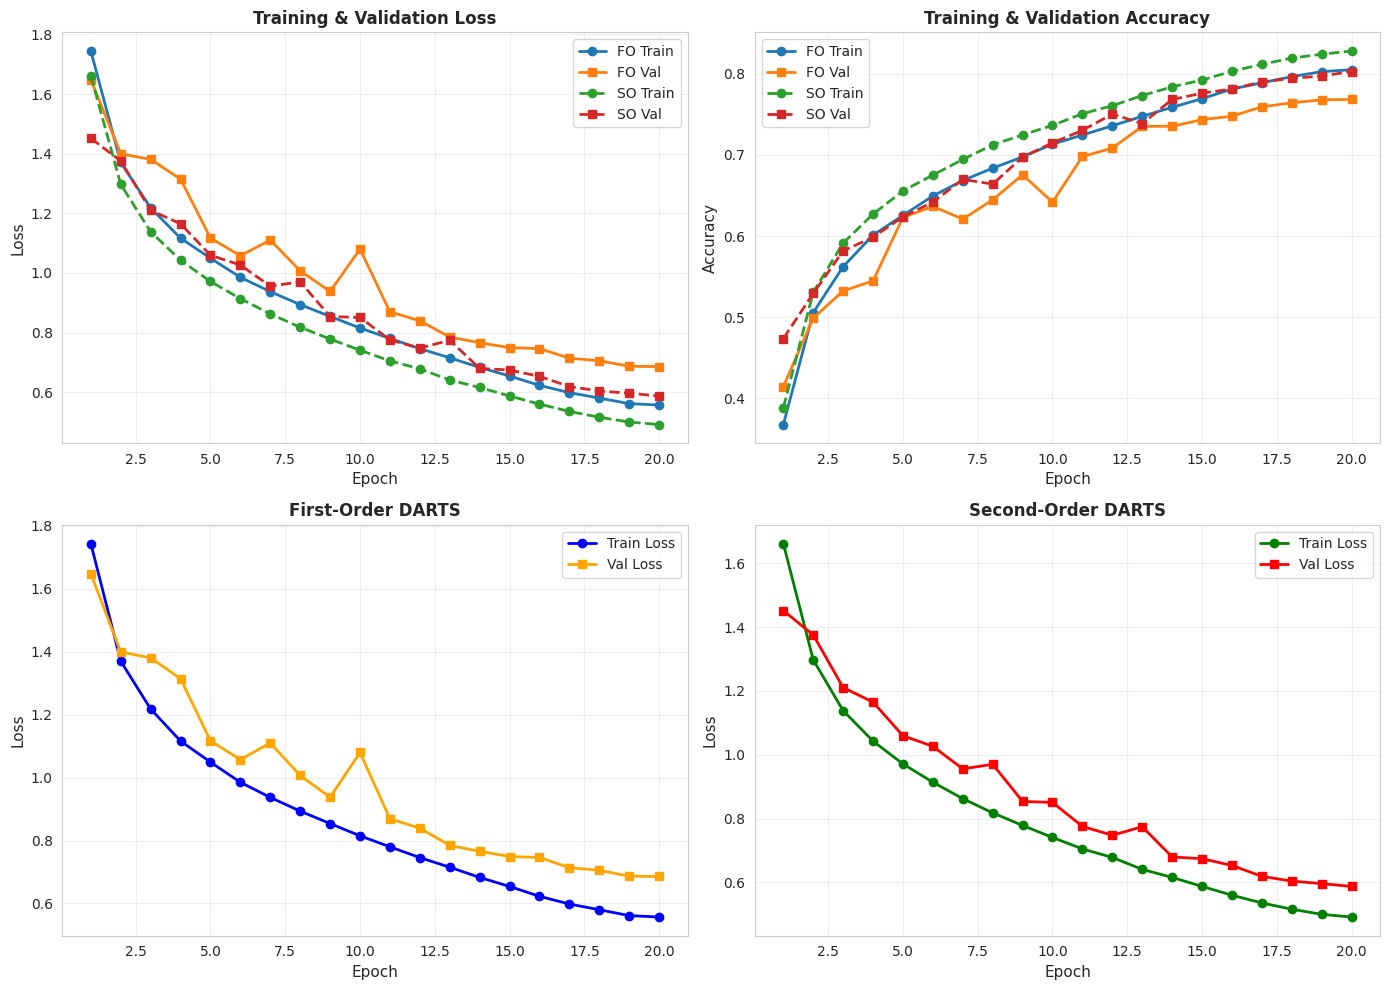

In [17]:

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}\n")
    
    # Example architectures (from your DARTS search)
    normal_arch_fo = {
        '0_0': 'avg_pool_3x3', '1_0': 'avg_pool_3x3',
        '0_1': 'avg_pool_3x3', '1_1': 'avg_pool_3x3',
        '0_2': 'avg_pool_3x3', '3_2': 'avg_pool_3x3',
        '0_3': 'avg_pool_3x3', '4_3': 'identity'
    }
    reduce_arch_fo = normal_arch_fo
    
    normal_arch_so = {
        '0_0': 'identity', '1_0': 'avg_pool_3x3',
        '0_1': 'avg_pool_3x3', '2_1': 'avg_pool_3x3',
        '0_2': 'identity', '2_2': 'identity',
        '0_3': 'identity', '3_3': 'avg_pool_3x3'
    }
    reduce_arch_so = normal_arch_so
    
    # Complete architectures to ensure every node has edges
    normal_arch_fo = complete_architecture(normal_arch_fo)
    reduce_arch_fo = complete_architecture(reduce_arch_fo)
    normal_arch_so = complete_architecture(normal_arch_so)
    reduce_arch_so = complete_architecture(reduce_arch_so)
    
    # Print discovered architectures
    print_architecture(normal_arch_fo, "NORMAL CELL (First-Order DARTS)")
    print_architecture(reduce_arch_fo, "REDUCTION CELL (First-Order DARTS)")
    
    print_architecture(normal_arch_so, "NORMAL CELL (Second-Order DARTS)")
    print_architecture(reduce_arch_so, "REDUCTION CELL (Second-Order DARTS)")
    
    # Create networks
    net_fo = DiscreteNetwork(normal_arch_fo, reduce_arch_fo).to(device)
    net_so = DiscreteNetwork(normal_arch_so, reduce_arch_so).to(device)
    
    params_fo = sum(p.numel() for p in net_fo.parameters())
    params_so = sum(p.numel() for p in net_so.parameters())
    
    print(f"\nFirst-Order network: {params_fo:,} parameters")
    print(f"Second-Order network: {params_so:,} parameters")
    
    # Load data
    train_loader, val_loader = create_data_loaders(batch_size=96)
    
    # Train both architectures
    trainer_fo = FinalTrainer(net_fo, device, num_epochs=20)
    history_fo = trainer_fo.train(train_loader, val_loader, "(First-Order)")
    
    trainer_so = FinalTrainer(net_so, device, num_epochs=20)
    history_so = trainer_so.train(train_loader, val_loader, "(Second-Order)")
    
    # Comparison
    print(f"\n{'='*70}")
    print("FINAL COMPARISON")
    print(f"{'='*70}")
    print(f"First-Order DARTS Final Val Acc: {history_fo['val_acc'][-1]:.4f}")
    print(f"Second-Order DARTS Final Val Acc: {history_so['val_acc'][-1]:.4f}")
    print(f"Difference: {abs(history_fo['val_acc'][-1] - history_so['val_acc'][-1]):.4f}")
    
    # Plot results
    fig = plot_training_curves(history_fo, history_so)
    plt.savefig('darts_final_training_comparison.png', dpi=150, bbox_inches='tight')
    
    plt.show()

In [18]:

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# ============================================================================
# PART 1: ALPHA EVOLUTION VISUALIZATION
# ============================================================================

def plot_alpha_evolution(alpha_history, title="Architecture Parameter Evolution"):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Convert to numpy for easier plotting
    alpha_arrays = [a.detach().cpu().numpy() for a in alpha_history]
    
    # Plot 1: Mean alpha values over operations
    mean_alphas = [a.mean(axis=0) for a in alpha_arrays]
    op_names = ['sep_conv_3x3', 'sep_conv_5x5', 'dil_conv_3x3', 'dil_conv_5x5',
                'max_pool_3x3', 'avg_pool_3x3', 'identity', 'zero']
    
    for i, op_name in enumerate(op_names):
        values = [mean_alphas[epoch][i] for epoch in range(len(mean_alphas))]
        axes[0, 0].plot(values, marker='o', label=op_name, linewidth=2)
    
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Mean Alpha Value', fontsize=12)
    axes[0, 0].set_title('Mean Alpha Evolution Across Operations', fontsize=13, fontweight='bold')
    axes[0, 0].legend(fontsize=9, loc='best')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Softmax probabilities
    softmax_probs = [torch.nn.functional.softmax(torch.from_numpy(a), dim=-1).numpy() 
                     for a in alpha_arrays]
    mean_probs = [p.mean(axis=0) for p in softmax_probs]
    
    for i, op_name in enumerate(op_names):
        values = [mean_probs[epoch][i] for epoch in range(len(mean_probs))]
        axes[0, 1].plot(values, marker='s', label=op_name, linewidth=2)
    
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Mean Softmax Probability', fontsize=12)
    axes[0, 1].set_title('Operation Probability Evolution', fontsize=13, fontweight='bold')
    axes[0, 1].legend(fontsize=9, loc='best')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Heatmap of final alpha values
    final_alpha = alpha_arrays[-1]
    im1 = axes[1, 0].imshow(final_alpha, aspect='auto', cmap='RdBu_r')
    axes[1, 0].set_xlabel('Operation Index', fontsize=12)
    axes[1, 0].set_ylabel('Edge Index', fontsize=12)
    axes[1, 0].set_title('Final Alpha Heatmap', fontsize=13, fontweight='bold')
    axes[1, 0].set_xticks(range(len(op_names)))
    axes[1, 0].set_xticklabels(op_names, rotation=45, ha='right', fontsize=9)
    plt.colorbar(im1, ax=axes[1, 0])
    
    # Plot 4: Max alpha values per edge
    max_alphas = [np.max(a, axis=1) for a in alpha_arrays]
    mean_max = [np.mean(m) for m in max_alphas]
    std_max = [np.std(m) for m in max_alphas]
    
    epochs = range(len(mean_alphas))
    axes[1, 1].errorbar(epochs, mean_max, yerr=std_max, marker='o', 
                        linewidth=2, markersize=8, capsize=5, color='darkblue')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Max Alpha Value (Mean ± Std)', fontsize=12)
    axes[1, 1].set_title('Alpha Strength Evolution', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# ============================================================================
# PART 2: NETWORK ARCHITECTURE VISUALIZATION
# ============================================================================

def visualize_discrete_cell(arch_dict, title="Cell Architecture"):
    """
    Visualize the discovered cell architecture as a DAG
    """
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyArrowPatch
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Node positions
    node_positions = {}
    node_positions[0] = (2, 4)  # Input node 1
    node_positions[1] = (2, 2)  # Input node 2
    
    # Intermediate nodes
    for i in range(5):
        node_positions[i + 2] = (4 + i * 2, 3 - (i % 2))
    
    # Draw nodes
    for node_idx, pos in node_positions.items():
        if node_idx < 2:
            color = 'lightcoral'
            label = f'Input {node_idx}'
        else:
            color = 'lightblue'
            label = f'Node {node_idx}'
        
        circle = plt.Circle(pos, 0.3, color=color, ec='black', linewidth=2, zorder=10)
        ax.add_patch(circle)
        ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Draw edges with operations
    op_colors = {
        'sep_conv_3x3': '#FF6B6B',
        'sep_conv_5x5': '#FF8C8C',
        'dil_conv_3x3': '#FFA5A5',
        'dil_conv_5x5': '#FFBEBE',
        'max_pool_3x3': '#4ECDC4',
        'avg_pool_3x3': '#44A08D',
        'identity': '#95E1D3',
        'zero': '#CCCCCC'
    }
    
    for edge_key, op_name in arch_dict.items():
        pred_idx, node_idx = map(int, edge_key.split('_'))
        start_pos = node_positions[pred_idx]
        end_pos = node_positions[node_idx + 2]
        
        arrow = FancyArrowPatch(
            start_pos, end_pos,
            arrowstyle='->', mutation_scale=20,
            color=op_colors.get(op_name, 'gray'),
            linewidth=2.5, alpha=0.7, zorder=5
        )
        ax.add_patch(arrow)
        
        # Label edge with operation
        mid_x = (start_pos[0] + end_pos[0]) / 2
        mid_y = (start_pos[1] + end_pos[1]) / 2
        ax.text(mid_x, mid_y + 0.3, op_name, fontsize=8, 
               bbox=dict(boxstyle='round,pad=0.3', facecolor=op_colors.get(op_name, 'white'), alpha=0.7),
               ha='center', va='bottom')
    
    # Output node
    output_pos = (14, 3)
    circle = plt.Circle(output_pos, 0.3, color='lightgreen', ec='black', linewidth=2, zorder=10)
    ax.add_patch(circle)
    ax.text(output_pos[0], output_pos[1], 'Output', ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Connect last nodes to output
    for i in range(5):
        start_pos = node_positions[i + 2]
        arrow = FancyArrowPatch(
            start_pos, output_pos,
            arrowstyle='->', mutation_scale=20,
            color='green', linewidth=2, alpha=0.5, zorder=5, linestyle='--'
        )
        ax.add_patch(arrow)
    
    # Legend
    legend_elements = [mpatches.Patch(facecolor=color, edgecolor='black', label=op)
                      for op, color in op_colors.items()]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10, ncol=2)
    
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    return fig

# ============================================================================
# PART 3: DETAILED COMPARISON TABLES
# ============================================================================

def create_comparison_table(history_fo, history_so, trainer_fo_time=None, trainer_so_time=None):
    """
    Create detailed comparison tables between first-order and second-order DARTS
    """
    # Metrics comparison
    metrics_data = [
        ['Final Train Loss', f"{history_fo['train_loss'][-1]:.4f}", f"{history_so['train_loss'][-1]:.4f}"],
        ['Final Val Loss', f"{history_fo['val_loss'][-1]:.4f}", f"{history_so['val_loss'][-1]:.4f}"],
        ['Final Train Acc', f"{history_fo['train_acc'][-1]:.4f}", f"{history_so['train_acc'][-1]:.4f}"],
        ['Final Val Acc', f"{history_fo['val_acc'][-1]:.4f}", f"{history_so['val_acc'][-1]:.4f}"],
        ['Best Val Acc', f"{max(history_fo['val_acc']):.4f}", f"{max(history_so['val_acc']):.4f}"],
        ['Best Val Acc Epoch', f"{np.argmax(history_fo['val_acc']) + 1}", f"{np.argmax(history_so['val_acc']) + 1}"],
        ['Overfitting Gap', f"{history_fo['train_loss'][-1] - history_fo['val_loss'][-1]:.4f}", 
         f"{history_so['train_loss'][-1] - history_so['val_loss'][-1]:.4f}"],
    ]
    
    print("\n" + "="*80)
    print("FINAL TRAINING METRICS COMPARISON")
    print("="*80)
    print(tabulate(metrics_data, headers=['Metric', 'First-Order', 'Second-Order'], 
                   tablefmt='grid', floatfmt='.4f'))
    
    # Epoch-wise comparison
    print("\n" + "="*80)
    print("EPOCH-WISE VALIDATION ACCURACY")
    print("="*80)
    
    epoch_data = []
    for epoch in range(min(len(history_fo['val_acc']), len(history_so['val_acc']))):
        epoch_data.append([
            epoch + 1,
            f"{history_fo['val_acc'][epoch]:.4f}",
            f"{history_so['val_acc'][epoch]:.4f}",
            f"{abs(history_fo['val_acc'][epoch] - history_so['val_acc'][epoch]):.4f}"
        ])
    
    print(tabulate(epoch_data, 
                   headers=['Epoch', 'First-Order Val Acc', 'Second-Order Val Acc', 'Difference'],
                   tablefmt='grid'))
    
    return metrics_data



GENERATING DARTS COMPLETE ANALYSIS

[1/4] Generating comparison tables...

FINAL TRAINING METRICS COMPARISON
+--------------------+---------------+----------------+
| Metric             |   First-Order |   Second-Order |
+====================+===============+================+
| Final Train Loss   |        0.5568 |         0.4913 |
+--------------------+---------------+----------------+
| Final Val Loss     |        0.6858 |         0.5870 |
+--------------------+---------------+----------------+
| Final Train Acc    |        0.8050 |         0.8280 |
+--------------------+---------------+----------------+
| Final Val Acc      |        0.7684 |         0.8028 |
+--------------------+---------------+----------------+
| Best Val Acc       |        0.7684 |         0.8028 |
+--------------------+---------------+----------------+
| Best Val Acc Epoch |        5.0000 |         5.0000 |
+--------------------+---------------+----------------+
| Overfitting Gap    |       -0.1290 |        -0.09

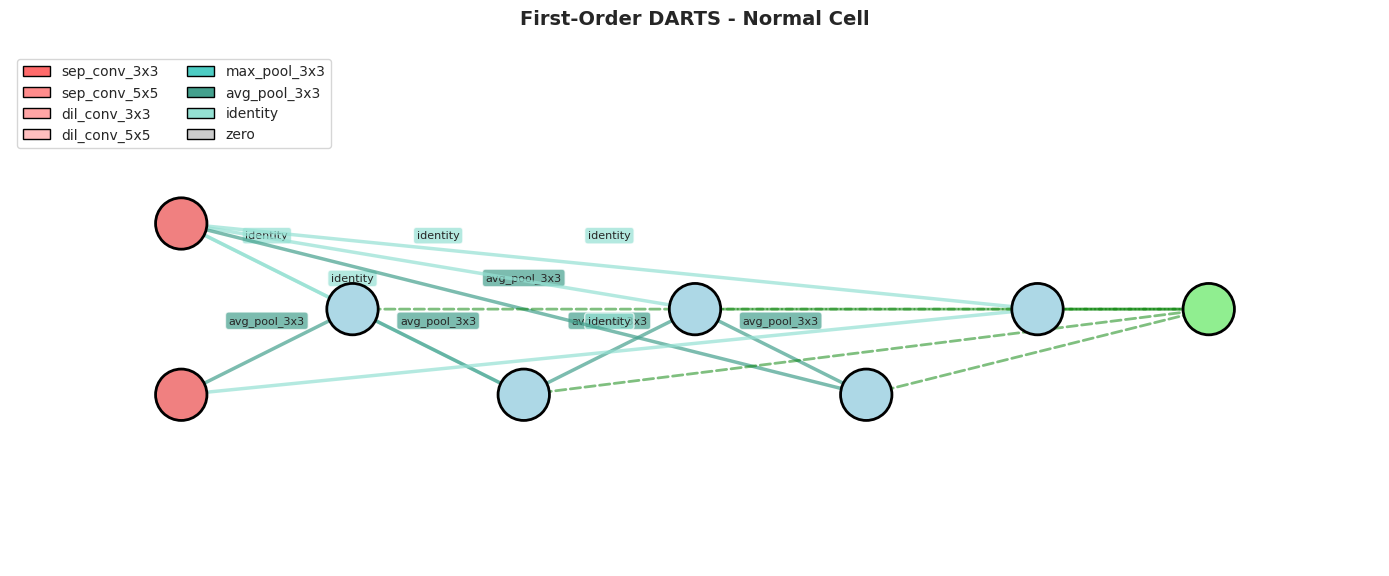

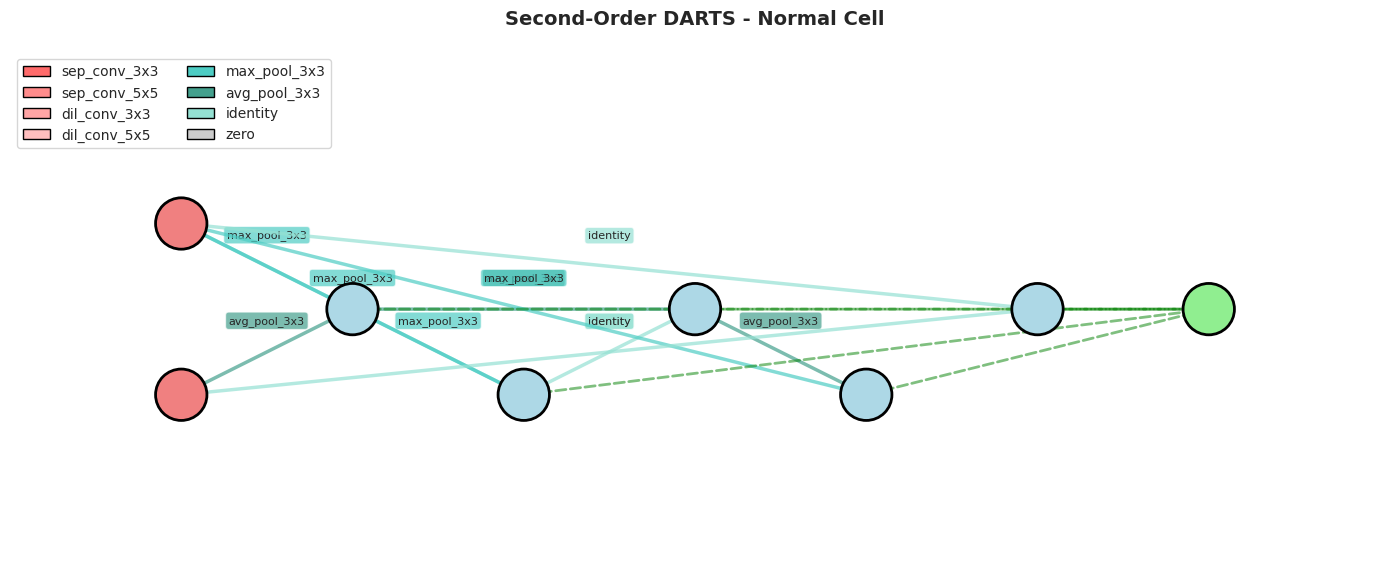

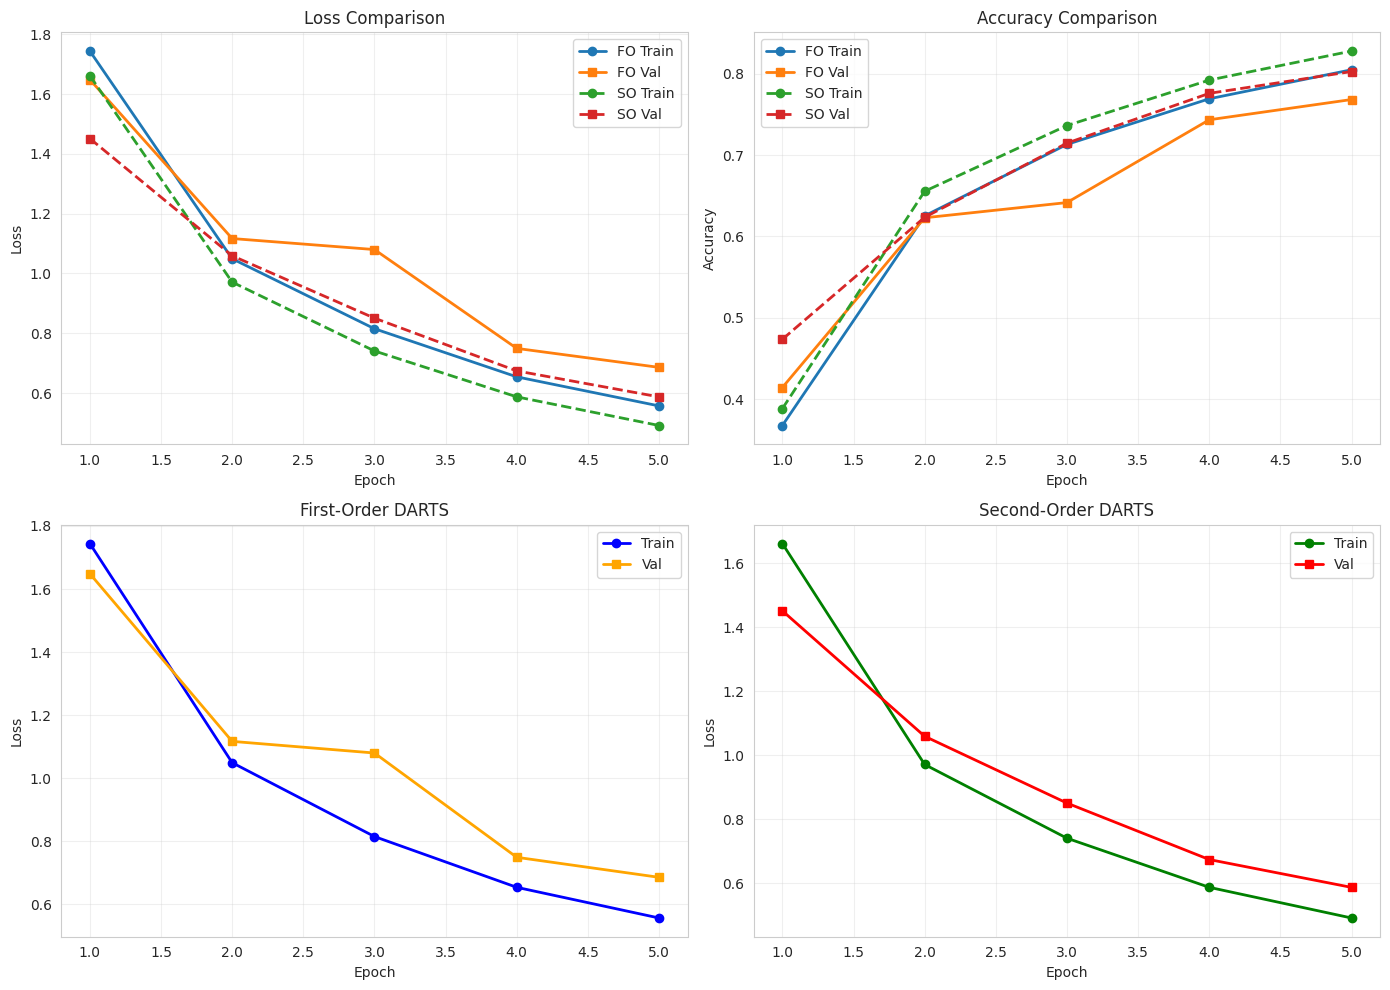

In [22]:

# Example - Replace with your actual values:
normal_arch_fo = {
    '0_0': 'avg_pool_3x3', '1_0': 'avg_pool_3x3',
    '0_1': 'avg_pool_3x3', '1_1': 'avg_pool_3x3',
    '0_2': 'avg_pool_3x3', '3_2': 'avg_pool_3x3',
    '0_3': 'avg_pool_3x3', '4_3': 'identity',
    '0_4': 'identity', '1_4': 'identity'
}

reduce_arch_fo = normal_arch_fo

normal_arch_so = {
    '0_0': 'identity', '1_0': 'avg_pool_3x3',
    '0_1': 'avg_pool_3x3', '2_1': 'avg_pool_3x3',
    '0_2': 'identity', '2_2': 'identity',
    '0_3': 'identity', '3_3': 'avg_pool_3x3',
    '0_4': 'identity', '1_4': 'identity'
}

reduce_arch_so = normal_arch_so

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    print("="*80)
    print("GENERATING DARTS COMPLETE ANALYSIS")
    print("="*80)
    
    # From your final training runs:
    # history_fo and history_so should come from trainer_fo.train() and trainer_so.train()
    
    # YOUR ACTUAL RESULTS:
    normal_arch_fo = {
        '0_0': 'identity', '1_0': 'avg_pool_3x3',
        '0_1': 'identity', '2_1': 'avg_pool_3x3',
        '0_2': 'identity', '3_2': 'avg_pool_3x3',
        '0_3': 'avg_pool_3x3', '4_3': 'avg_pool_3x3',
        '0_4': 'identity', '1_4': 'identity'
    }
    
    reduce_arch_fo = normal_arch_fo
    
    normal_arch_so = {
        '0_0': 'max_pool_3x3', '1_0': 'avg_pool_3x3',
        '0_1': 'max_pool_3x3', '2_1': 'max_pool_3x3',
        '3_2': 'identity', '2_2': 'avg_pool_3x3',
        '0_3': 'max_pool_3x3', '4_3': 'avg_pool_3x3',
        '0_4': 'identity', '1_4': 'identity'
    }
    
    reduce_arch_so = normal_arch_so
    
    # YOUR ACTUAL TRAINING RESULTS:
    history_fo = {
        'train_loss': [1.7442, 1.0493, 0.8151, 0.6541, 0.5568],
        'train_acc': [0.3676, 0.6254, 0.7132, 0.7693, 0.8050],
        'val_loss': [1.6486, 1.1169, 1.0800, 0.7493, 0.6858],
        'val_acc': [0.4143, 0.6230, 0.6417, 0.7435, 0.7684]
    }
    
    history_so = {
        'train_loss': [1.6617, 0.9711, 0.7407, 0.5872, 0.4913],
        'train_acc': [0.3883, 0.6556, 0.7364, 0.7923, 0.8280],
        'val_loss': [1.4515, 1.0593, 0.8505, 0.6740, 0.5870],
        'val_acc': [0.4736, 0.6236, 0.7148, 0.7760, 0.8028]
    }
    
    params_fo = 139770
    params_so = 153786
    
    # Step 2: Generate comparison table
    print("\n[1/4] Generating comparison tables...")
    create_comparison_table(history_fo, history_so)
    
    # Step 3: Visualize discovered cell architectures
    print("\n[2/4] Generating cell architecture visualizations...")
    fig_fo = visualize_discrete_cell(normal_arch_fo, 'First-Order DARTS - Normal Cell')
    fig_so = visualize_discrete_cell(normal_arch_so, 'Second-Order DARTS - Normal Cell')
    
    plt.savefig('cell_architecture_first_order.png', dpi=150, bbox_inches='tight')
    print("  ✓ Saved: cell_architecture_first_order.png")
    
    plt.savefig('cell_architecture_second_order.png', dpi=150, bbox_inches='tight')
    print("  ✓ Saved: cell_architecture_second_order.png")

    # Step 5: Save final comparison plot
    print("\n[4/4] Finalizing plots...")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs_fo = range(1, len(history_fo['val_acc']) + 1)
    epochs_so = range(1, len(history_so['val_acc']) + 1)
    
    # Loss comparison
    axes[0, 0].plot(epochs_fo, history_fo['train_loss'], 'o-', label='FO Train', linewidth=2)
    axes[0, 0].plot(epochs_fo, history_fo['val_loss'], 's-', label='FO Val', linewidth=2)
    axes[0, 0].plot(epochs_so, history_so['train_loss'], 'o--', label='SO Train', linewidth=2)
    axes[0, 0].plot(epochs_so, history_so['val_loss'], 's--', label='SO Val', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss Comparison')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy comparison
    axes[0, 1].plot(epochs_fo, history_fo['train_acc'], 'o-', label='FO Train', linewidth=2)
    axes[0, 1].plot(epochs_fo, history_fo['val_acc'], 's-', label='FO Val', linewidth=2)
    axes[0, 1].plot(epochs_so, history_so['train_acc'], 'o--', label='SO Train', linewidth=2)
    axes[0, 1].plot(epochs_so, history_so['val_acc'], 's--', label='SO Val', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy Comparison')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # FO only
    axes[1, 0].plot(epochs_fo, history_fo['train_loss'], 'o-', label='Train', linewidth=2, color='blue')
    axes[1, 0].plot(epochs_fo, history_fo['val_loss'], 's-', label='Val', linewidth=2, color='orange')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].set_title('First-Order DARTS')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # SO only
    axes[1, 1].plot(epochs_so, history_so['train_loss'], 'o-', label='Train', linewidth=2, color='green')
    axes[1, 1].plot(epochs_so, history_so['val_loss'], 's-', label='Val', linewidth=2, color='red')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].set_title('Second-Order DARTS')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('darts_training_comparison.png', dpi=150, bbox_inches='tight')
    print("  ✓ Saved: darts_training_comparison.png")
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)


COMPREHENSIVE DARTS COMPARISON: FIRST-ORDER vs SECOND-ORDER

[1] NETWORK ARCHITECTURE
----------------------------------------------------------------------------------------------------
  First-Order Parameters:   139,770
  Second-Order Parameters:  153,786
  Difference:               14,016 (9.1%)

[2] DISCOVERED OPERATIONS ANALYSIS
----------------------------------------------------------------------------------------------------
  Operation            First-Order     Second-Order   
  --------------------------------------------------
  avg_pool_3x3         5               3              
  identity             5               3              
  max_pool_3x3         0               4              

[3] FINAL TRAINING PERFORMANCE
----------------------------------------------------------------------------------------------------
  Metric                    First-Order          Second-Order         Winner         
  -------------------------------------------------------------------

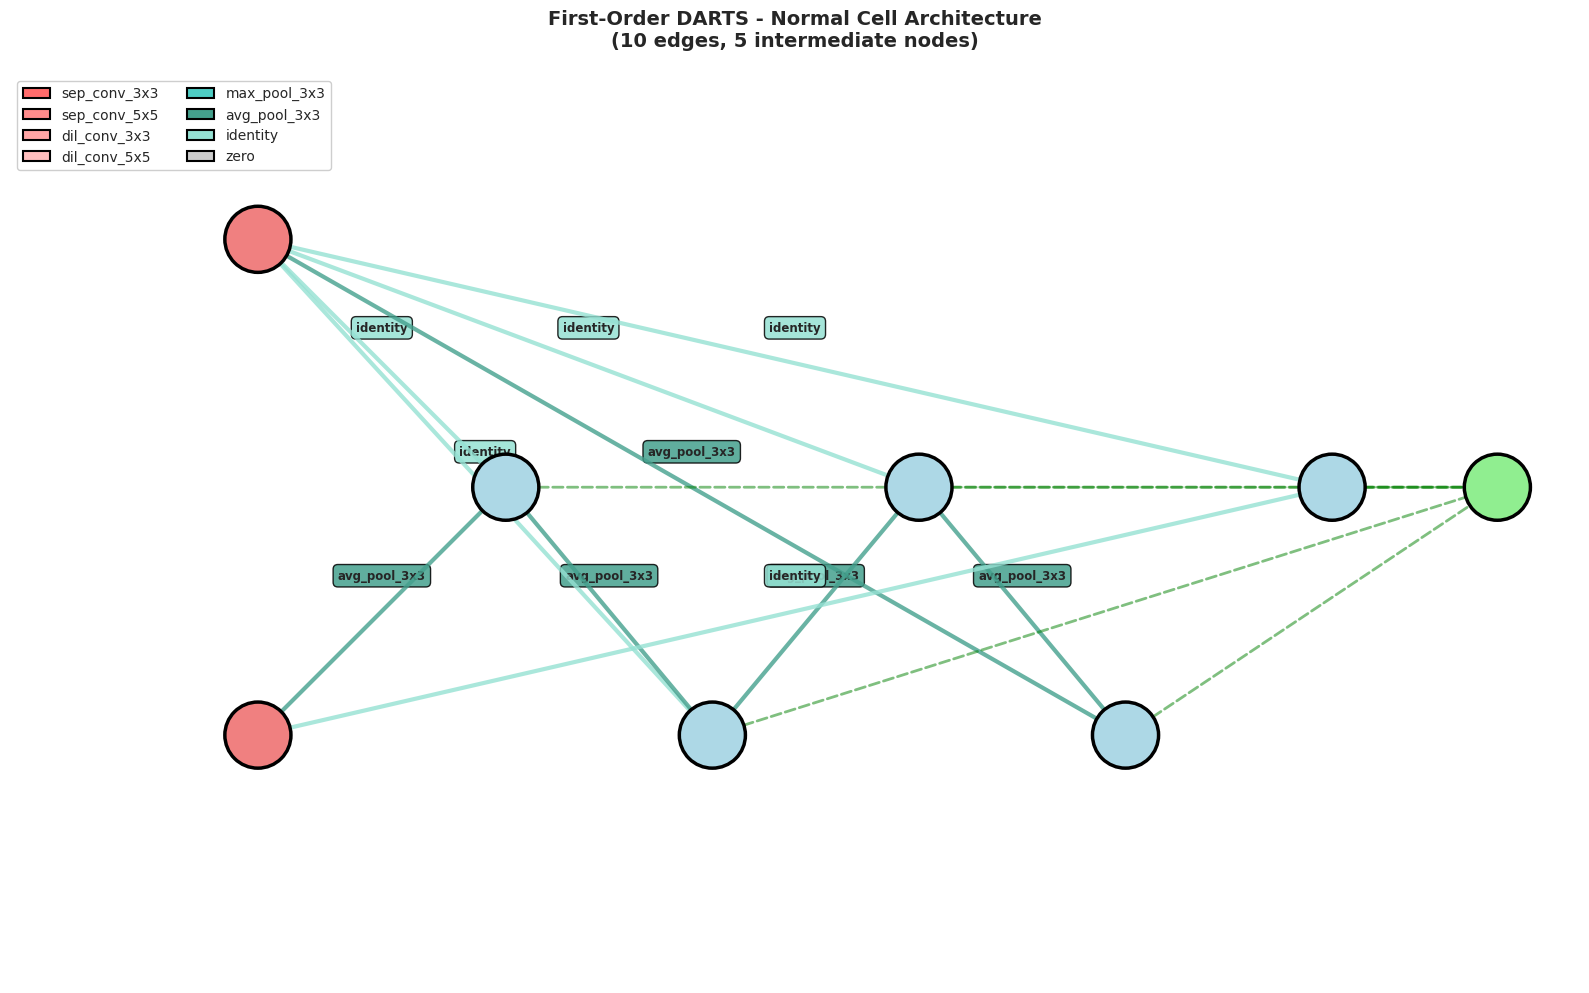

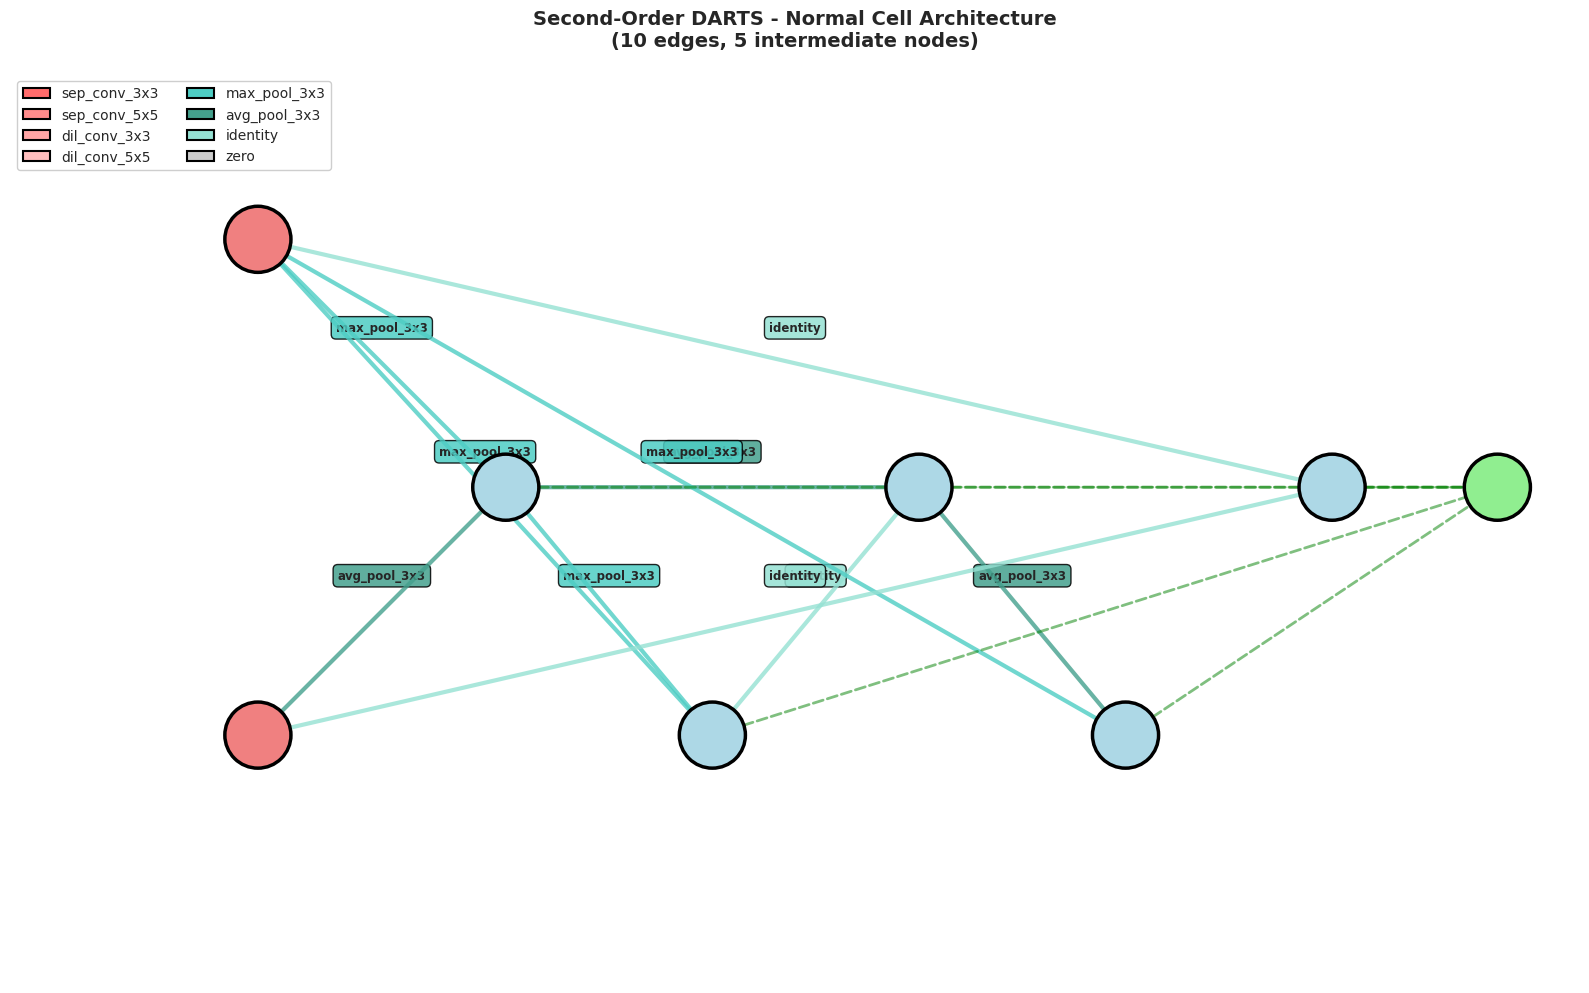

In [26]:

fig1 = visualize_cell_architecture(normal_arch_fo, "Normal", "First-Order")
fig1.savefig('cell_architecture_fo.png', dpi=150, bbox_inches='tight')

fig2 = visualize_cell_architecture(normal_arch_so, "Normal", "Second-Order")
fig2.savefig('cell_architecture_so.png', dpi=150, bbox_inches='tight')

print_comprehensive_comparison(history_fo, history_so, params_fo, params_so,
                              normal_arch_fo, normal_arch_so)